#### (번외)불량 유형별 예측

In [201]:
# y: Defects 그룹 전체 (멀티라벨)
#y_cols = [c for c in df.columns if c[0] == 'Defects']
#y = df[y_cols].astype(int)

# X: Process + Sensor 
#X = df[[c for c in df.columns if c[0] in ('Process', 'Sensor')]].copy()
#X = X.drop(columns=[('Process', 'id')], errors='ignore')
#X = X.drop(columns=[('Process', 'Product_Type')], errors='ignore')

#print("X:", X.shape, "y:", y.shape)
#print("y columns (first 10):", y.columns[:10].tolist())

# 환경설정하기

In [202]:
# 라이브러리 Import
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("="*60)


라이브러리 로드 완료!


### 데이터 로드

In [214]:
df1 = pd.read_csv("../../data/product_type_1.csv", header=[0, 1])
df = df1.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (process, id)                   2653 non-null   int64  
 1   (process, product_type)         2653 non-null   int64  
 2   (process, shot)                 2653 non-null   int64  
 3   (process, velocity_1)           2653 non-null   float64
 4   (process, velocity_2)           2653 non-null   float64
 5   (process, velocity_3)           2653 non-null   float64
 6   (process, high_velocity)        2653 non-null   float64
 7   (process, cylinder_pressure)    2653 non-null   int64  
 8   (process, rapid_rise_time)      2653 non-null   float64
 9   (process, biscuit_thickness)    2653 non-null   int64  
 10  (process, clamping_force)       2653 non-null   int64  
 11  (process, cycle_time)           2653 non-null   float64
 12  (process, pressure_rise_time)   2653 non-null

In [216]:
print("="*60)
print("남은 defects 컬럼 확인")
print("="*60)

df[[c for c in df.columns if c[0] == 'defects']].info()

남은 defects 컬럼 확인
<class 'pandas.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   (defects, short_shot_1)   2653 non-null   int64
 1   (defects, bubble_1)       2653 non-null   int64
 2   (defects, exfoliation_1)  2653 non-null   int64
 3   (defects, stain_1)        2653 non-null   int64
 4   (defects, dent_1)         2653 non-null   int64
 5   (defects, deformation_1)  2653 non-null   int64
 6   (defects, short_shot_2)   2653 non-null   int64
 7   (defects, bubble_2)       2653 non-null   int64
 8   (defects, exfoliation_2)  2653 non-null   int64
 9   (defects, deformation_2)  2653 non-null   int64
dtypes: int64(10)
memory usage: 207.4 KB


## 불량 여부 이진 분류

### 타겟 | ('Defect_Flag','Is_Defect')

In [207]:
print("결측치 상위:\n", df.isnull().sum().sort_values(ascending=False).head(10))

print("\n불량 비율:\n", df[('defect_flag','is_defect')].value_counts(normalize=True))

결측치 상위:
 process  id                   0
         product_type         0
         shot                 0
         velocity_1           0
         velocity_2           0
         velocity_3           0
         high_velocity        0
         cylinder_pressure    0
         rapid_rise_time      0
         biscuit_thickness    0
dtype: int64

불량 비율:
 (defect_flag, is_defect)
0    0.782887
1    0.217113
Name: proportion, dtype: float64


### header[0,1] 인 멀티인덱스 컬럼을 단일헤더로 변경하기

In [208]:
df.columns = ['_'.join(col) for col in df.columns]
df.head()

,process_id,process_product_type,process_shot,process_velocity_1,process_velocity_2,process_velocity_3,process_high_velocity,process_cylinder_pressure,process_rapid_rise_time,process_biscuit_thickness,process_clamping_force,process_cycle_time,process_pressure_rise_time,process_casting_pressure,process_spray_time,process_spray_1_time,process_spray_2_time,sensor_melting_furnace_temp,sensor_air_pressure,sensor_air_pressure_min,sensor_air_pressure_max,sensor_coolant_temp,sensor_coolant_temp_min,sensor_coolant_temp_max,sensor_coolant_pressure,sensor_factory_temp,sensor_factory_temp_min,sensor_factory_temp_max,sensor_factory_humidity,sensor_factory_humidity_min,sensor_factory_humidity_max,defects_short_shot_1,defects_bubble_1,defects_exfoliation_1,defects_stain_1,defects_dent_1,defects_deformation_1,defects_short_shot_2,defects_bubble_2,defects_exfoliation_2,defects_deformation_2,defect_flag_is_defect
0,1,1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,3,9,26.0,10,50,2.71,32.9,18.0,22.0,58.4,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0
1,1002,1,2,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0
2,2003,1,3,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0
3,3004,1,4,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,1,0,0,0,0,0,0,0,1
4,4005,1,5,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,3,9,26.1,10,50,2.69,32.9,18.0,22.0,57.8,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0


In [209]:
y = df[[c for c in df.columns if c.startswith('defects')]]
X = df[[c for c in df.columns if c.startswith(('process','sensor'))]]

X = X.drop(columns=[
    ('process_id'),
    ('process_product_type')
])

pip install iterative-stratification


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", X_train.shape)
print("test:", X_test.shape)

print("train 불량률:", y_train.mean())
print("test 불량률:", y_test.mean())

print("")
print("="*60)
print(f"데이터 분포 유지됨")

print(f"랜덤 split이 잘 됨")

print(f"모델 평가 신뢰도 높음")
print("="*60)


ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: ['0 0 0 0 0 1 1 0 0 0', '0 0 0 1 0 0 0 0 0 0', '0 0 0 1 0 0 0 1 0 0', '0 0 1 1 0 0 0 0 0 0', '1 0 0 0 0 1 0 0 0 1', '1 0 1 0 0 0 0 0 0 0']

In [ ]:
print("결측치 개수 합계:", X_train.isnull().sum().sum()) # train_set.isnull().sum().sum()

print("="*60)
print("결측치 없음!")
print("="*60)

결측치 개수 합계: 0
결측치 없음!


In [ ]:
X_train.dtypes

process  shot                      int64
         velocity_1              float64
         velocity_2              float64
         velocity_3              float64
         high_velocity           float64
         cylinder_pressure         int64
         rapid_rise_time         float64
         biscuit_thickness         int64
         clamping_force            int64
         cycle_time              float64
         pressure_rise_time      float64
         casting_pressure          int64
         spray_time              float64
         spray_1_time            float64
         spray_2_time            float64
sensor   melting_furnace_temp    float64
         air_pressure            float64
         air_pressure_min          int64
         air_pressure_max          int64
         coolant_temp            float64
         coolant_temp_min          int64
         coolant_temp_max          int64
         coolant_pressure        float64
         factory_temp            float64
         factory

## X Train data 정보 확인

In [ ]:
print(X_train.shape)
print(X_train.info())


(2122, 29)
<class 'pandas.DataFrame'>
Index: 2122 entries, 528 to 1791
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (process, shot)                 2122 non-null   int64  
 1   (process, velocity_1)           2122 non-null   float64
 2   (process, velocity_2)           2122 non-null   float64
 3   (process, velocity_3)           2122 non-null   float64
 4   (process, high_velocity)        2122 non-null   float64
 5   (process, cylinder_pressure)    2122 non-null   int64  
 6   (process, rapid_rise_time)      2122 non-null   float64
 7   (process, biscuit_thickness)    2122 non-null   int64  
 8   (process, clamping_force)       2122 non-null   int64  
 9   (process, cycle_time)           2122 non-null   float64
 10  (process, pressure_rise_time)   2122 non-null   float64
 11  (process, casting_pressure)     2122 non-null   int64  
 12  (process, spray_time)           2122 

In [ ]:
display(X_train.describe())

process                                                       \
              shot   velocity_1   velocity_2   velocity_3 high_velocity   
count  2122.000000  2122.000000  2122.000000  2122.000000   2122.000000   
mean    545.798303     0.143168     0.168786     0.182214      2.135592   
std     356.067339     0.003815     0.004658     0.006356      0.077473   
min       1.000000     0.136000     0.162000     0.172000      0.000000   
25%     229.000000     0.142000     0.168000     0.178000      2.122000   
50%     519.500000     0.142000     0.168000     0.182000      2.137000   
75%     840.000000     0.144000     0.170000     0.186000      2.153000   
max    1296.000000     0.180000     0.212000     0.234000      2.285000   

                                                                          \
      cylinder_pressure rapid_rise_time biscuit_thickness clamping_force   
count       2122.000000     2122.000000       2122.000000    2122.000000   
mean         218.899152        0.008056         11.658812     256.015551   
std            8.113249        0.001481          1.372763       2.249259   
min          107.000000        0.000000          0.000000     238.000000   
25%          215.000000        0.008000         11.000000     254.000000   
50%          217.000000        0.008000         12.000000     257.000000   
75%          218.000000        0.008000         12.000000     258.000000   
max          241.000000        0.021000         22.000000     263.000000   

                                                                     \
        cycle_time pressure_rise_time casting_pressure   spray_time   
count  2122.000000        2122.000000      2122.000000  2122.000000   
mean     21.364373           0.041761      1059.463713     8.235344   
std       6.465165           0.003106        39.149478     0.581471   
min      20.300000           0.000000       516.000000     7.000000   
25%      20.700000           0.041000      1039.000000     7.900000   
50%      20.900000           0.043000      1052.000000     8.000000   
75%      21.100000           0.044000      1054.000000     8.300000   
max     218.600000           0.046000      1164.000000    10.800000   

                                              sensor               \
      spray_1_time spray_2_time melting_furnace_temp air_pressure   
count  2122.000000  2122.000000           2122.00000  2122.000000   
mean      0.931008     0.790104            699.74557     6.129972   
std       0.145787     0.044352             13.66537     0.580223   
min       0.700000     0.700000            671.00000     4.600000   
25%       0.800000     0.800000            689.30000     5.800000   
50%       1.000000     0.800000            700.60000     6.200000   
75%       1.000000     0.800000            708.90000     6.600000   
max       1.200000     1.000000            730.00000     7.100000   

                                                                       \
      air_pressure_min air_pressure_max coolant_temp coolant_temp_min   
count           2122.0           2122.0  2122.000000           2122.0   
mean               3.0              9.0    26.760933             10.0   
std                0.0              0.0     0.471624              0.0   
min                3.0              9.0    25.900000             10.0   
25%                3.0              9.0    26.400000             10.0   
50%                3.0              9.0    26.800000             10.0   
75%                3.0              9.0    27.100000             10.0   
max                3.0              9.0    28.100000             10.0   

                                                                       \
      coolant_temp_max coolant_pressure factory_temp factory_temp_min   
count           2122.0      2122.000000  2122.000000           2122.0   
mean              50.0         2.709025    33.528228             18.0   
std                0.0         0.041896     1.918871              0.0   
m

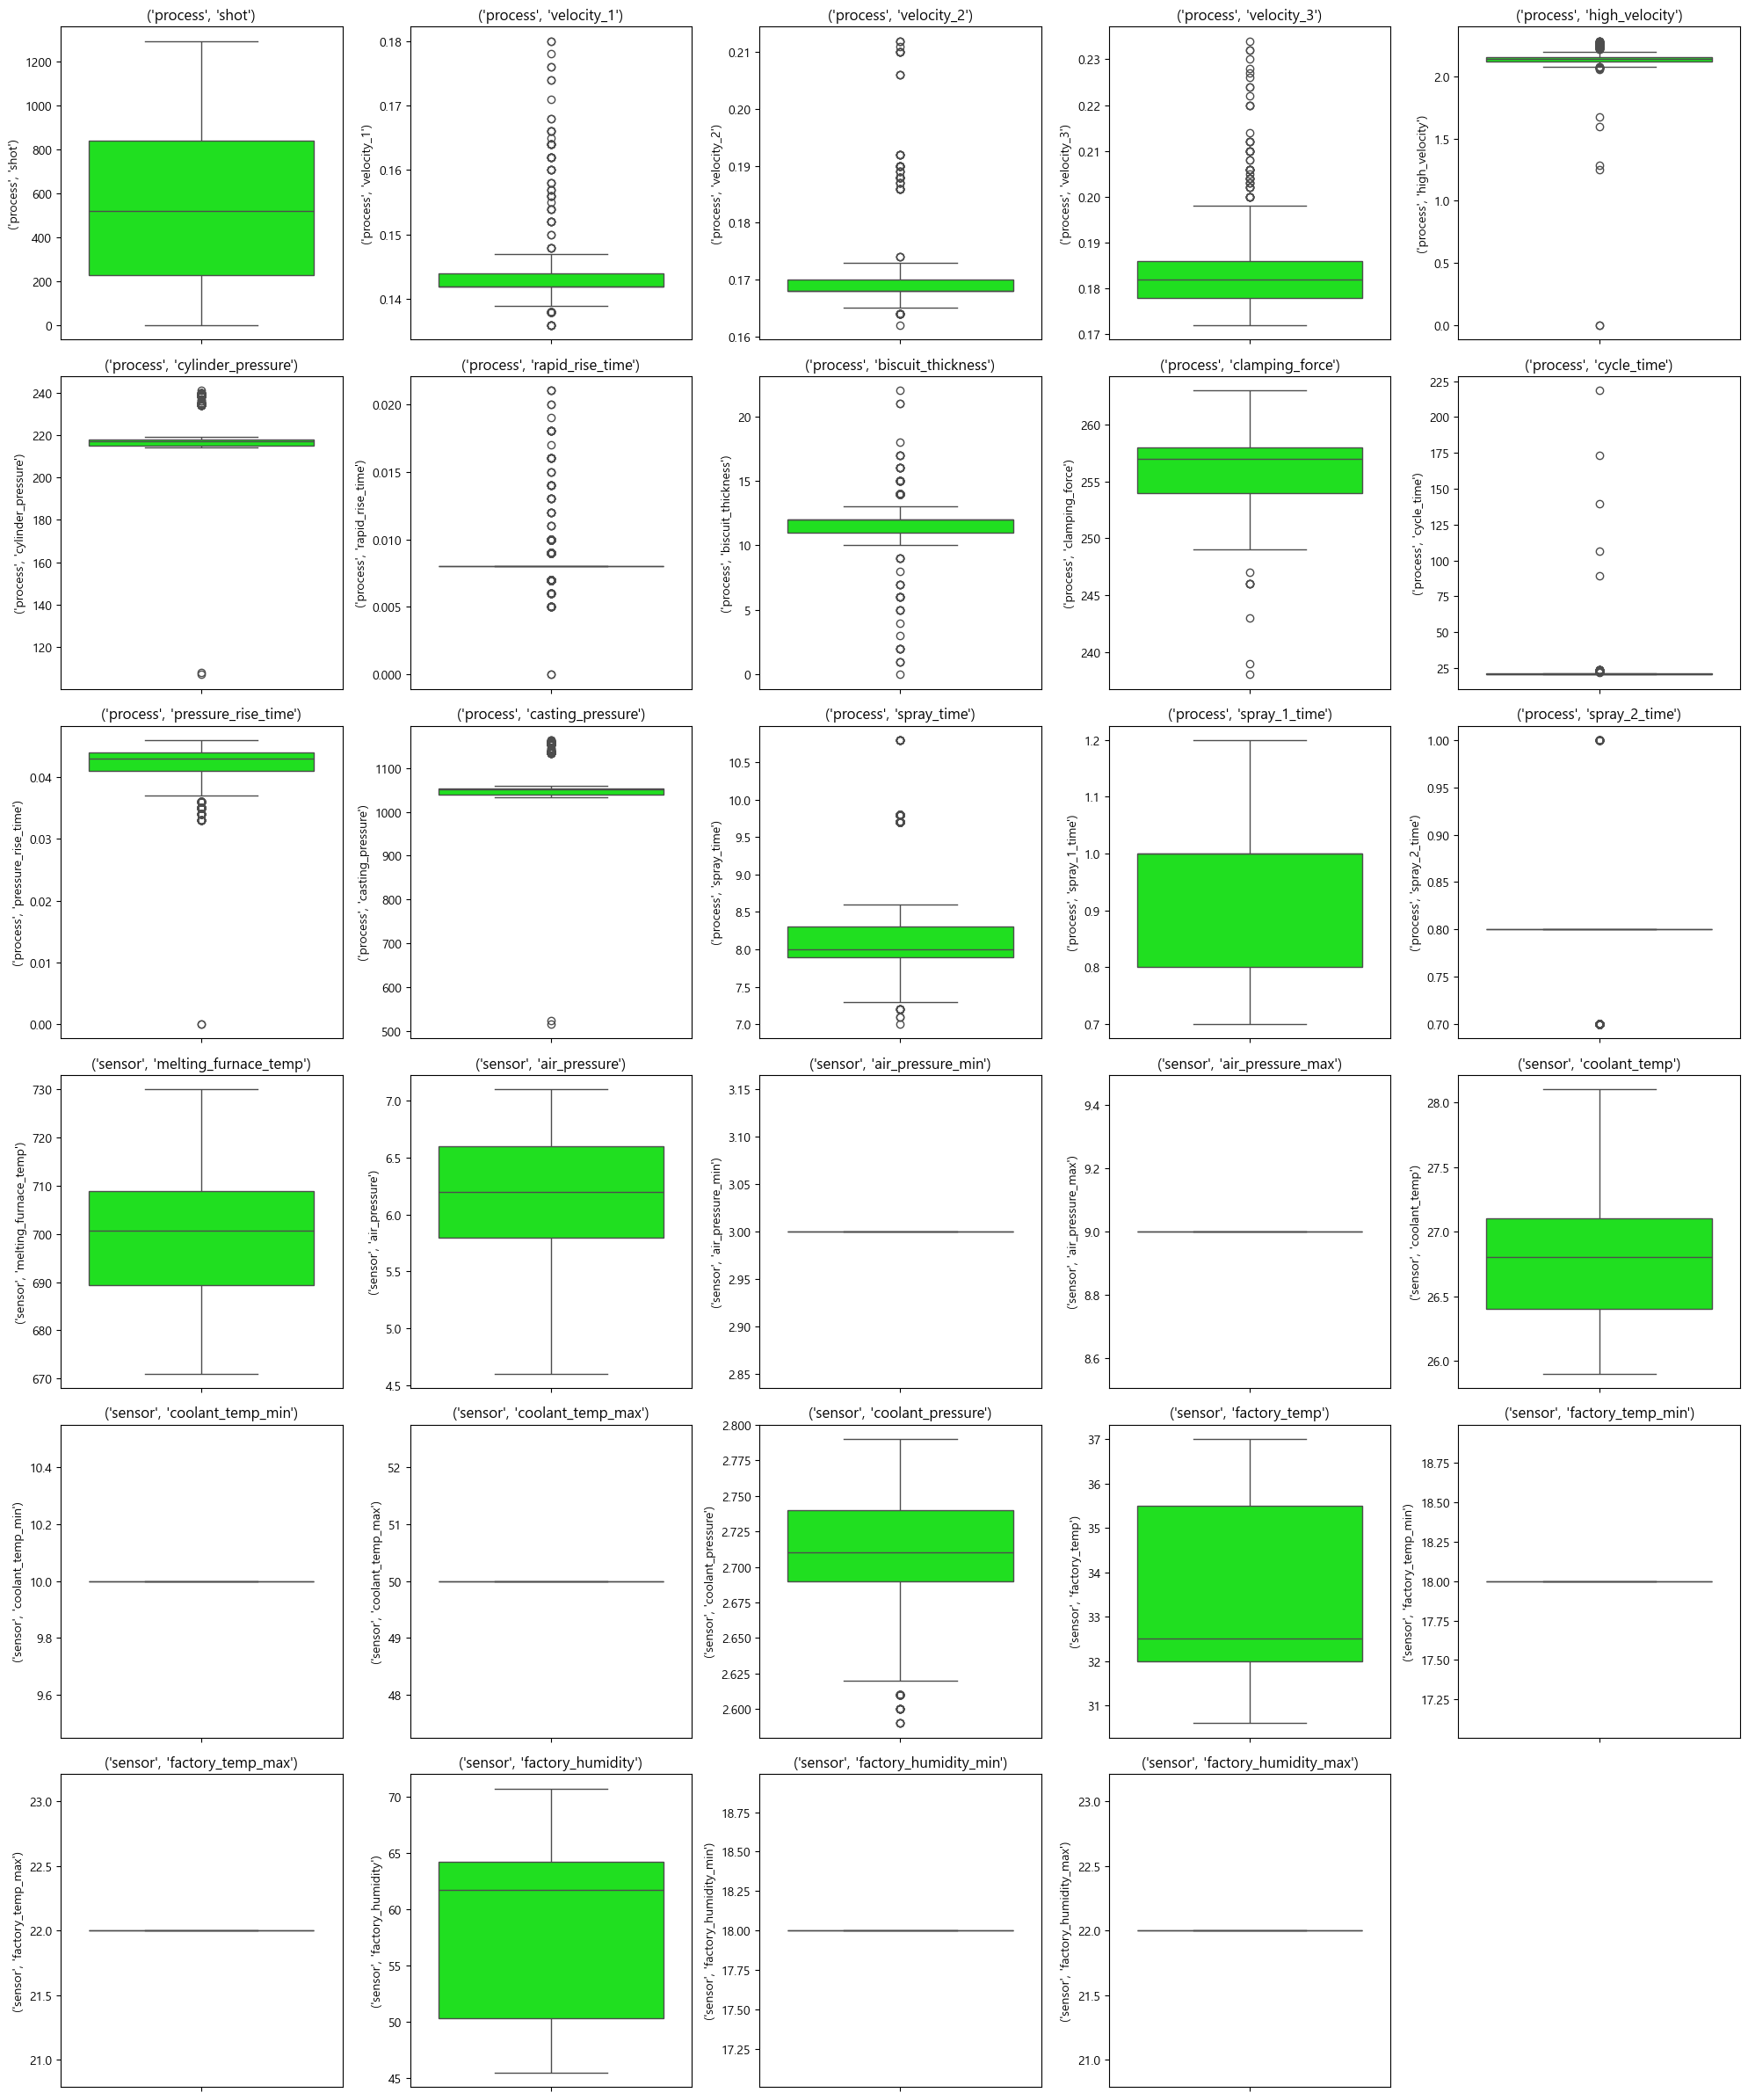

In [ ]:
# 박스플롯

cols = X_train.columns

n_cols = 5   # 한 행에 5개
n_rows = (len(cols) // n_cols) + 1

plt.figure(figsize=(20, 4*n_rows))

for i, col in enumerate(cols, 1):
    
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=X_train[col], color='lime')
    plt.title(str(col))
    
plt.tight_layout()
plt.show()

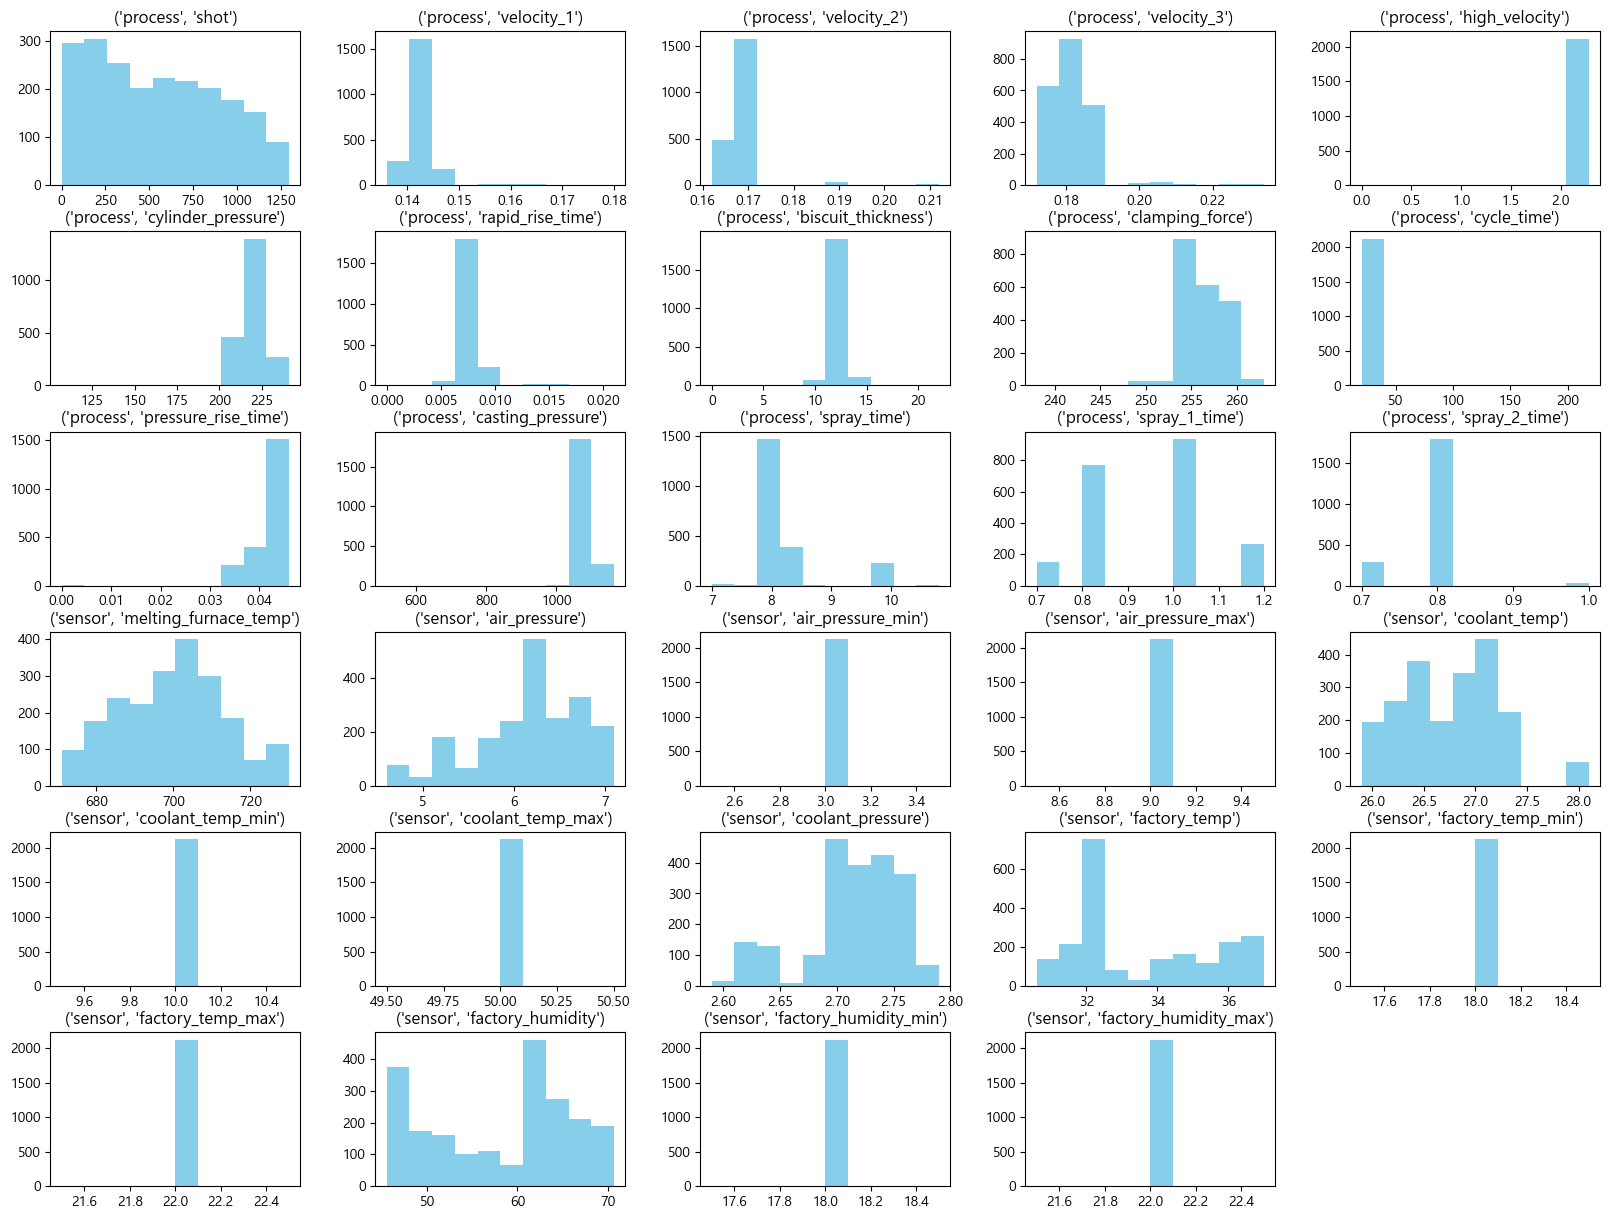

In [ ]:
X_train.hist(figsize=(20,15), grid = False, color='skyblue')
plt.show()

#### feature 간 상관관계 - multicollinearity 확인

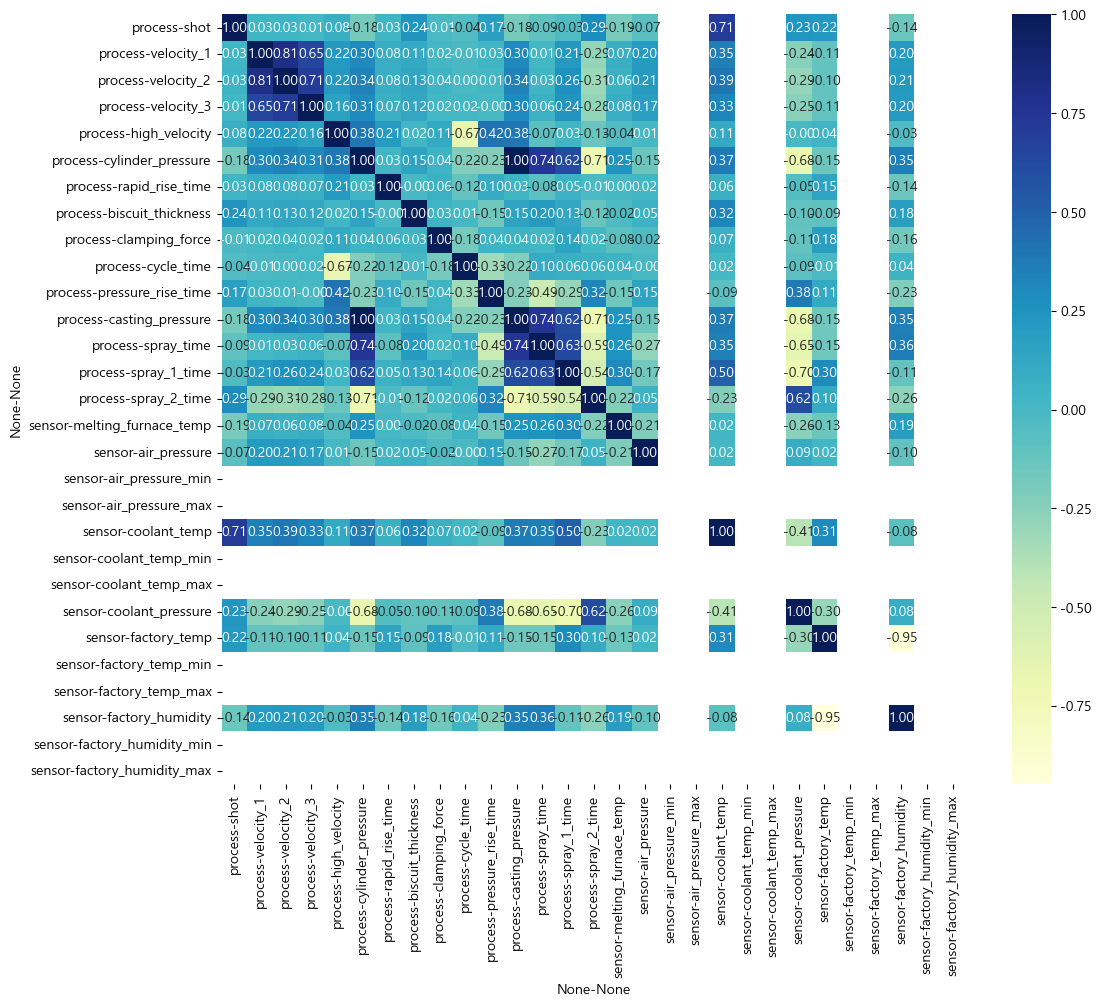

In [ ]:
corr = X_train.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="YlGnBu",
    annot=True,      
    fmt=".2f"        
)

plt.show()

## y 타겟(불량) 분포 확인 

In [ ]:
y_train.value_counts(normalize=True)

(defect_flag, is_defect)
0    0.782752
1    0.217248
Name: proportion, dtype: float64

Class imbalance 확인


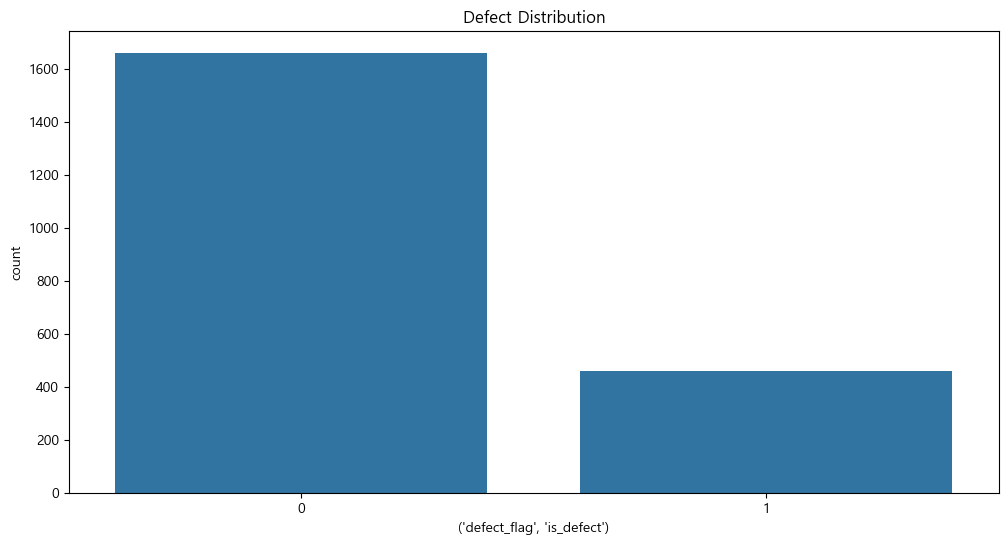

In [ ]:
# 정상 불량 분포 확인하기


print("="*60)
print("Class imbalance 확인")
print("="*60)

sns.countplot(x=y_train)
plt.title("Defect Distribution")
plt.show()



### 간단한 RandomForest로 중요 변수 확인해보기

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

process  shot                    0.123881
sensor   factory_humidity        0.100866
         melting_furnace_temp    0.079965
process  high_velocity           0.078562
sensor   factory_temp            0.063728
process  velocity_3              0.057602
sensor   coolant_pressure        0.052039
process  casting_pressure        0.051958
sensor   air_pressure            0.049623
process  velocity_1              0.044348
dtype: float64